# M8.3C — Channel capacity

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report** (Fourier-base is assumed in M8 Steps / M9 freeze).

**Conclusion:** Spatial info dominates; wider Fourier helps with diminishing returns → retain **Fourier-base (3A geometry)** as primary; Flatten remains absolute reference.

Train each grid variant with **`N_REPEAT`** seeds (default 5). Smoke defaults keep wall time low. Results CSVs land under `checkpoints/m8/m08_3c_channel_capacity/`.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = True
RUN_STUDY = None  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}


In [4]:
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    architecture_grid_dataframe,
    load_m8_catalog_rows,
    load_win3c_results,
    plot_win3c_results,
    run_win3c_channel_capacity_study,
    summarize_win3c,
    win3c_results_dir,
    win3c_task_specs,
    win3_grids_summary,
)

results_dir = win3c_results_dir(ROOT)
print(f"results_dir={display_path(results_dir)}")


results_dir=checkpoints/m8/m08_3c_channel_capacity


## Milestone 8 Step 3C predefined grid

In [5]:
display(win3_grids_summary()['3C_channel_capacity'])


,arch_name,head_type,encoder_channels,downsample,maxpool_after_blocks,pool_schedule,pre_flatten_channels,embed_dim,flatten_hidden,flatten_head,input_representation,normalisation
0,pooled_base_base,pooled,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,128,mlp,anomaly_ref,none
1,fourier_narrow_base,fourier,"(8, 16, 32)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,1,linear,anomaly_ref,none
2,fourier_base_base,fourier,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,1,linear,anomaly_ref,none
3,fourier_wide_base,fourier,"(32, 64, 128)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,1,linear,anomaly_ref,none
4,flatten_base_base,flatten,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",None,128,128,mlp,anomaly_ref,none


## Contract test

In [6]:
run_installed_pytest_test(m8_validation, "test_m8_3c_channel_capacity_includes_fourier_base")


M8.3C
Test executed: test_m8_3c_channel_capacity_includes_fourier_base()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.71s ===============================

Test proves: Milestone 8 Step 3C channel-capacity grid includes Fourier-base.


## Train / validation study

In [7]:
rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
train_task, val_task, _ = win3c_task_specs()
train_ds = build_task_dataset(rows, train_task)
val_ds = build_task_dataset(rows, val_task)

summary_df, runs_df = load_win3c_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else (runs_df is None or runs_df.empty)
if should_run:
    summary_df, runs_df, _ = run_win3c_channel_capacity_study(
        train_ds,
        val_ds,
        train_task,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
else:
    print("Loaded existing runs CSV — set RUN_STUDY=True to retrain.")

display(summary_df)



######## Milestone 8 Step 3C repeat 1/5  seed=0 ########
  pooled_base_base rep 1 epoch 001/40  train_loss=37.94574  val_RMSE=5.5863  best=5.5863*  stall=0/25
  pooled_base_base rep 1 epoch 002/40  train_loss=31.41950  val_RMSE=5.2991  best=5.2991*  stall=0/25
  pooled_base_base rep 1 epoch 003/40  train_loss=29.69275  val_RMSE=5.1313  best=5.1313*  stall=0/25
  pooled_base_base rep 1 epoch 004/40  train_loss=29.60785  val_RMSE=5.1195  best=5.1195*  stall=0/25
  pooled_base_base rep 1 epoch 005/40  train_loss=29.16921  val_RMSE=5.1355  best=5.1195   stall=1/25
  pooled_base_base rep 1 epoch 006/40  train_loss=29.30027  val_RMSE=5.1129  best=5.1129*  stall=0/25
  pooled_base_base rep 1 epoch 007/40  train_loss=29.73951  val_RMSE=5.1467  best=5.1129   stall=1/25
  pooled_base_base rep 1 epoch 008/40  train_loss=29.40385  val_RMSE=5.0959  best=5.0959*  stall=0/25
  pooled_base_base rep 1 epoch 009/40  train_loss=28.40529  val_RMSE=5.0414  best=5.0414*  stall=0/25
  pooled_base_base rep 1

,experiment_id,win,architecture_factor,hypothesis,head_type,downsample,encoder_channels,architecture_config,parameter_count,feature_map_hw,...,interpretation,train_RMSE_total_mean,train_RMSE_total_std,validation_RMSE_total_mean,validation_RMSE_total_std,best_validation_RMSE_total_mean,best_validation_RMSE_total_std,variant,n_repeat,seeds
3,win3c__fourier_wide_base,3C,channel_capacity,channel_width_limits_fourier_spatial_modes,fourier,base,"[32, 64, 128]","{""arch_name"": ""fourier_wide_base"", ""head_type""...",109571,"(128, 128)",...,,1.186054,0.049225,1.545870,0.056044,1.545870,0.056044,fourier_wide_base,5,"0,1,2,3,4"
4,win3c__flatten_base_base,3C,channel_capacity,channel_width_limits_fourier_spatial_modes,flatten,base,"[16, 32, 64]","{""arch_name"": ""flatten_base_base"", ""head_type""...",134249859,"(128, 128)",...,,0.876027,0.106361,1.579729,0.102803,1.579729,0.102803,flatten_base_base,5,"0,1,2,3,4"
2,win3c__fourier_base_base,3C,channel_capacity,channel_width_limits_fourier_spatial_modes,fourier,base,"[16, 32, 64]","{""arch_name"": ""fourier_base_base"", ""head_type""...",31811,"(128, 128)",...,,1.335761,0.058694,1.706505,0.097919,1.706505,0.097919,fourier_base_base,5,"0,1,2,3,4"
1,win3c__fourier_narrow_base,3C,channel_capacity,channel_width_limits_fourier_spatial_modes,fourier,base,"[8, 16, 32]","{""arch_name"": ""fourier_narrow_base"", ""head_typ...",10211,"(128, 128)",...,,1.723631,0.329831,1.964636,0.314092,1.964636,0.314092,fourier_narrow_base,5,"0,1,2,3,4"
0,win3c__pooled_base_base,3C,channel_capacity,channel_width_limits_fourier_spatial_modes,pooled,base,"[16, 32, 64]","{""arch_name"": ""pooled_base_base"", ""head_type"":...",32003,"(128, 128)",...,,4.442731,0.258615,4.371883,0.243056,4.371883,0.243056,pooled_base_base,5,"0,1,2,3,4"


## Results

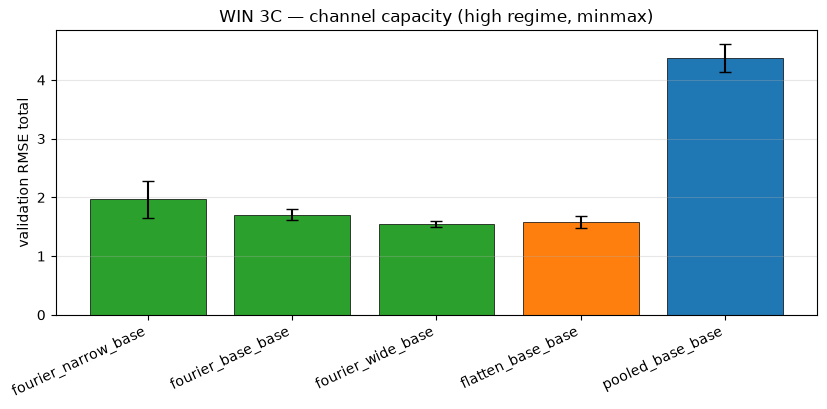

- Fourier channel sweep: best=fourier_wide_base (1.546), range 0.419 over fourier_narrow_base→fourier_wide_base.

- Retain Fourier-base (16,32,64) as primary — wider/narrower are secondary checks.

- Flatten reference mean val RMSE 1.580 (absolute readout upper bound).

- Aggregated over n=5 seeds (mean ± std).

In [8]:
fig = plot_win3c_results(summary_df, runs_df=runs_df)
plt.show()
for line in summarize_win3c(summary_df):
    display(Markdown(f"- {line}"))


## Conclusions

1. All effects are relatively small, showing that at least within the Fourier approach, the exact network details are not of major importance.
2. Wider MLP improves performance slightly, narrower MLP degrades it more significantly.

Given that the effects are rather minor, the canonical network architecture is maintained.

Do **not** freeze architecture here (Milestone 8 Step 3E). Did **not** touch the test split.
